In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [99]:
df_index = pd.read_csv("economic_index.csv")
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


Drop unnesscary columns

In [100]:
df_index.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [101]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [102]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

visualization

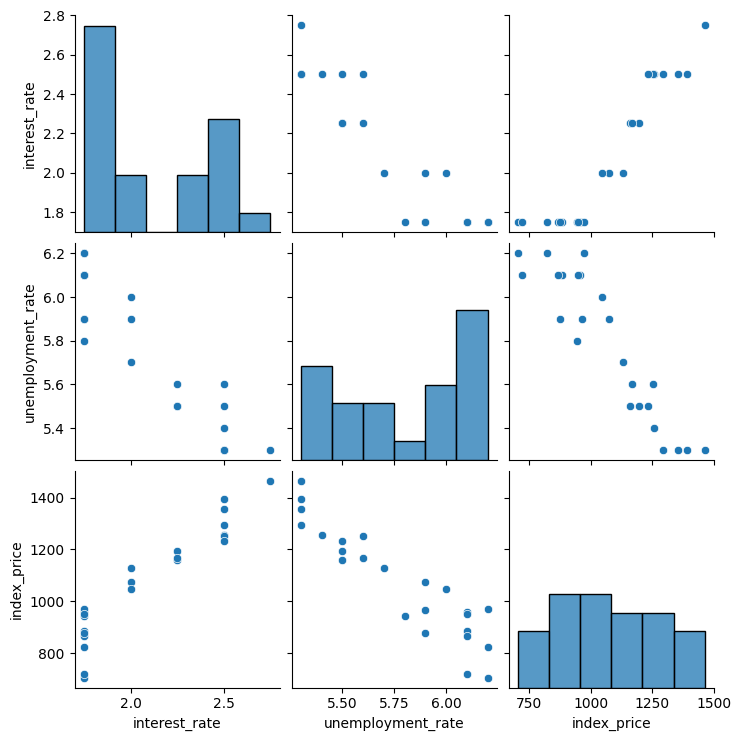

In [103]:
import seaborn as sns
sns.pairplot(df_index)

In [104]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

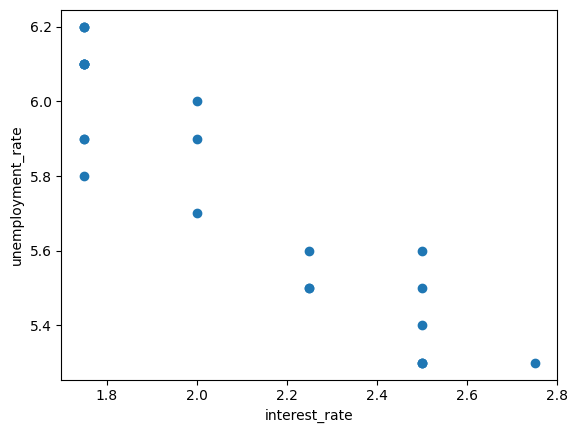

In [105]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'])
plt.xlabel("interest_rate")
plt.ylabel("unemployment_rate")

In [106]:
## independent and dependent features
x=df_index[['interest_rate','unemployment_rate']] 
y=df_index['index_price']

In [107]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [108]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

trainn test split

In [109]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

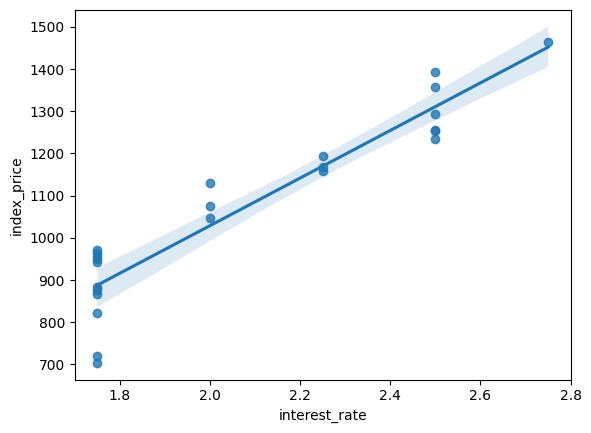

In [110]:
sns.regplot(
    x=df_index['interest_rate'],
    y=df_index['index_price']
)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

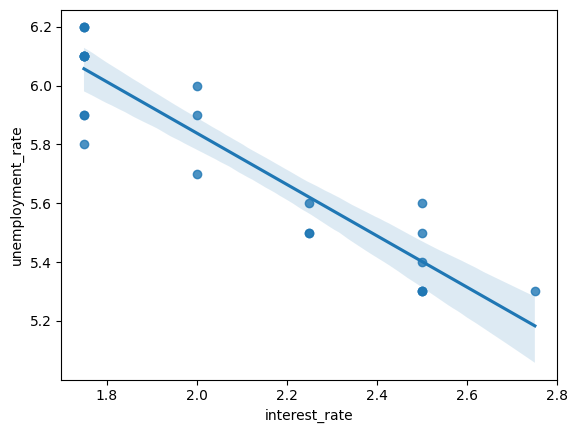

In [111]:
sns.regplot(
    x=df_index['interest_rate'],
    y=df_index['unemployment_rate']
)

In [112]:
from sklearn.preprocessing import StandardScaler

In [113]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test) 

In [114]:
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [115]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [116]:
regression.fit(x_train,y_train)  # .fit() ka matlab?

#Model ko training data se relationship sikhana.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Cross Validation — `cross_val_score`

## 🔹 What is Cross Validation?

Cross Validation ka use **model ki performance ko multiple times check karne** ke liye hota hai.

Normally hum data ko ek baar train aur test mein divide karte hain:

    100% Data
       ↓
    ┌───────┬───────┐
    │ Train │  Test │
    │  75%  │  25%  │
    └───────┴───────┘

Lekin ek hi split se hume ye guarantee nahi hoti ki model har type ke data par achha perform karega.

Isliye Cross Validation mein data ko multiple parts (Folds) mein divide karke
model ko baar-baar train aur test kiya jata hai.

---

## 🔹 `cross_val_score`

`cross_val_score` sklearn ka function hai jo **Cross Validation perform karke
har fold ka performance score return karta hai.**

### Syntax:

```python
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

In [117]:
from sklearn.model_selection import cross_val_score
val_score=cross_val_score(regression, x_train, y_train,scoring='neg_mean_squared_error', cv=3)


In [118]:
val_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [119]:
np.mean(val_score)

np.float64(-5914.828180162386)

prediction

In [120]:
y_pred=regression.predict(x_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [121]:
## performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error:",mse)
print("Mean Absolute Error:",mae)
print("Root Mean Squared Error:",rmse)
print("R2 Score:",r2)

Mean Squared Error: 5793.762887712569
Mean Absolute Error: 59.935781523235484
Root Mean Squared Error: 76.11677139574805
R2 Score: 0.8278978091457145


    Assumptions

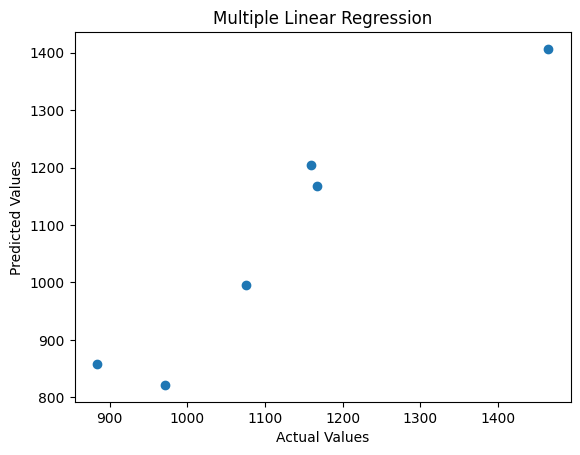

In [122]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression")
plt.show()

In [123]:
#Residual kya hota hai?
#Residual = Actual value − Predicted value
residuals = y_test - y_pred
print(residuals)
# it measures the model’s prediction error.


8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


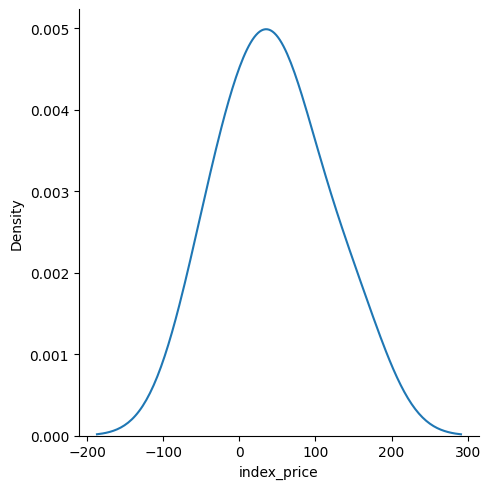

In [124]:
sns.displot(residuals,kind='kde')

In [125]:
## OLS LINEAR REGRESSION
import statsmodels.api as sm
model=sm.OLS(y_train, x_train).fit()

In [126]:
predictions=model.predict(x_test)
print(predictions)

[ 150.78325954 -231.79392541  353.06855924 -195.73554836  -58.53452146
  114.72488249]
